## Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Fast Fourier Transform (FFT)

## Practice 1: STFT for Sine Function

### 1-1. Define freqeuncies (f) and angular frequencies (w) to generate a sine function

In [2]:
# Frequencies (Hz)
f1 = 2
f2 = 3
f3 = 5
f4 = 21
f5 = 30

# Angular frequencies = 2pi*f (rad/s)
w1 = 2*np.pi*f1
w2 = 2*np.pi*f2
w3 = 2*np.pi*f3
w4 = 2*np.pi*f4
w5 = 2*np.pi*f5

In [3]:
print("f1 =",f1, "/ f2 =",f2, "/ f3 =",f3, "/ f4 =",f4, "/ f5 =",f5 )
print("w1 =",w1, "/ w2 =",w2, "/ w3 =",w3, "/ w4 =",w4, "/ w5 =",w5 )

f1 = 2 / f2 = 3 / f3 = 5 / f4 = 21 / f5 = 30
w1 = 12.566370614359172 / w2 = 18.84955592153876 / w3 = 31.41592653589793 / w4 = 131.94689145077132 / w5 = 188.49555921538757


### 1-2. Generate a NON-STATIONARY sine function (discrete)

In [4]:
t = np.arange(0,10,0.005)  # Sampling freq : 200 Hz, sampling time : 10 seconds

x = np.concatenate([np.sin(w1*t), np.sin(w2*t), np.sin(w3*t), np.sin(w4*t), np.sin(w5*t)])
# Compare to stationary sine function below:
# x = 5*np.sin(w1*t) + 4*np.sin(w2*t) + 3*np.sin(w3*t) + 2*np.sin(w4*t) + 1*np.sin(w5*t)

t_total = np.arange(0, 50, 0.005)

t.shape, t_total.shape, x.shape

((2000,), (10000,), (10000,))

### 1-3. Check the NON-STATIONARY sine function graph in time domain

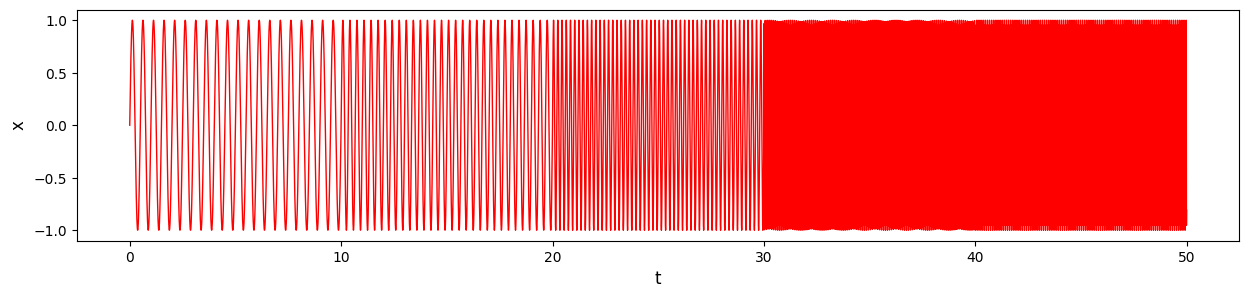

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(t_total, x, 'r-', lw = 1)
plt.xlabel('t',fontsize=12)
plt.ylabel('x',fontsize=12)
#plt.xlim(0,1)
plt.show()

### 1-4. Implement the STFT

#### 1-4-1. Calculate sampling frequency (Fs)
- Fs = Number of sample / sampling time

In [5]:
Fs = int(len(t)/t[-1]) # sampling freq
Fs

200

#### 1-4-2. SFFT implementation
[Key parameters]
* nperseg : Length (number of point) of each segment
* noverlap: Number of points to overlap between segments (typically 20~30% of nperseg)

In [6]:
from scipy import signal

f,t,Sxx = signal.spectrogram(x, Fs, nperseg = 500, noverlap = 200) # STFT function
f.shape, t.shape, Sxx.shape

((251,), (32,), (251, 32))

#### 1-4-3. Plot STFT result

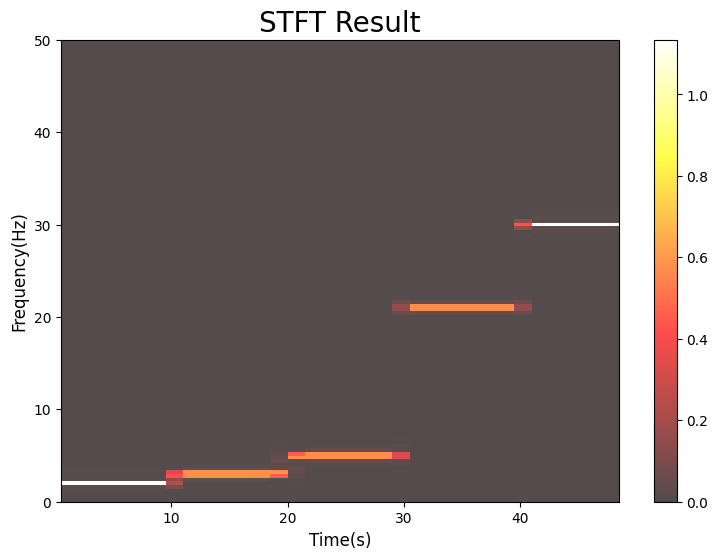

In [ ]:
plt.figure(figsize=(9,6))

plt.pcolormesh(t, f, Sxx, cmap='hot', alpha=0.7)

plt.ylim((0, 50)) # Frequency ragne: 0Hz ~ 50Hz
plt.xlabel('Time(s)', fontsize=12)
plt.ylabel('Frequency(Hz)', fontsize=12)
plt.title('STFT Result', fontsize=20)
plt.colorbar()

plt.show()

.

.

.

.

.

.

## Practice 2: STFT for Data

### 2-1. Load data

In [7]:
# Load data with column names
path = 'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/ML1/ExampleData?raw=true'
Data = pd.read_csv(path, sep=',',names=['time(s)', 'Acceleration(g)', 'Voltage(V)', 'Current(kA)'])
Data

,time(s),Acceleration(g),Voltage(V),Current(kA)
0,0.000000,0.016440,-0.014200,0.001433
1,0.000078,0.013822,-0.015707,0.001504
2,0.000156,0.019431,-0.016963,0.001433
3,0.000234,0.003726,-0.017248,0.001549
4,0.000313,0.022049,-0.009840,0.001864
...,...,...,...,...
2769,0.216330,0.077392,0.002404,0.003453
2770,0.216410,0.030276,0.003952,0.003498
2771,0.216480,0.017188,0.005504,0.003397
2772,0.216560,0.037754,-0.000108,0.003506


### 2-2. Check the time domain graph
* Plot the Votage signal in time domain

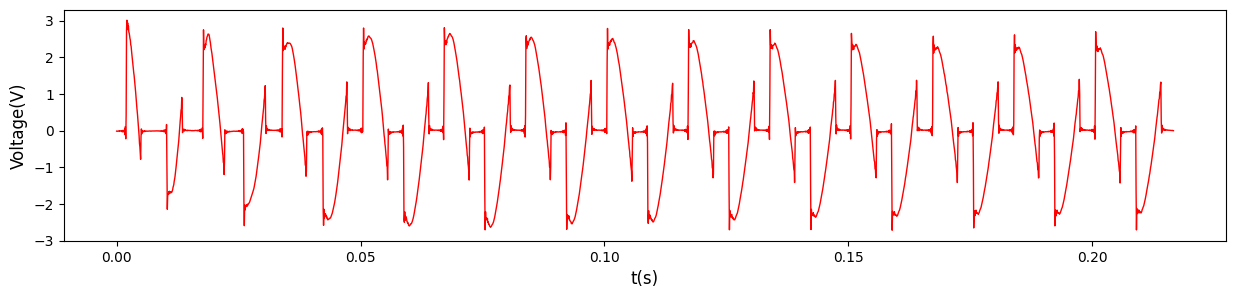

In [13]:
# Insert your code

plt.figure(figsize=(15,3))
plt.plot( Data.iloc[:,0], Data.iloc[:,2], 'r-', lw = 1)
plt.xlabel('t(s)',fontsize=12)
plt.ylabel('Voltage(V)',fontsize=12)
plt.show()

### 2-3. Implement the STFT

#### 2-3-1. Declare sampling frequency (Fs) and target data (x)

In [14]:
Fs = 12800                 # Sampling frequency
x  = Data.iloc[:,2].values # Select a signal array of data

#### 2-3-2. STFT implementation

In [19]:
# Insert your code
from scipy import signal

f,t,Sxx = signal.spectrogram(x, Fs, nperseg = 256, noverlap = 128) # STFT function
f.shape, t.shape, Sxx.shape


((129,), (20,), (129, 20))

#### 2-3-4. Plot STFT result
* Try to set ylim range from 0 Hz to 500 Hz

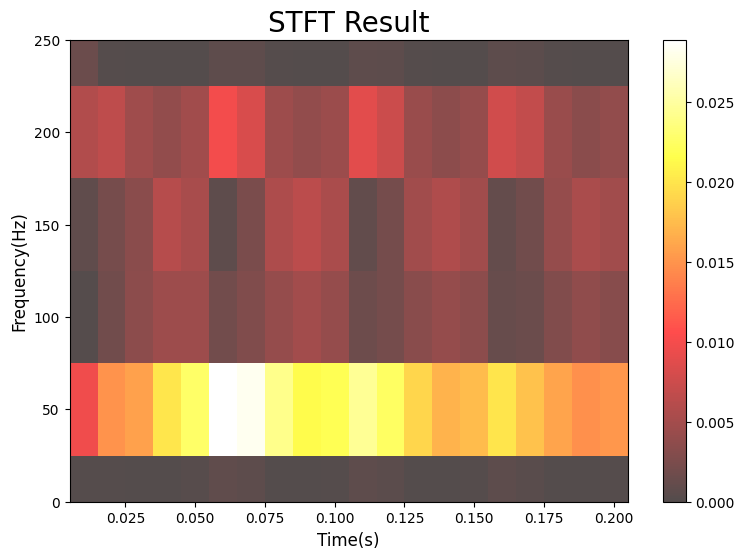

In [23]:
# Insert your code

plt.figure(figsize=(9,6))

plt.pcolormesh(t, f, Sxx, cmap='hot', alpha=0.7)

plt.ylim((0, 250)) # Frequency ragne: 0Hz ~ 50Hz
plt.xlabel('Time(s)', fontsize=12)
plt.ylabel('Frequency(Hz)', fontsize=12)
plt.title('STFT Result', fontsize=20)
plt.colorbar()

plt.show()